# Project 4 — Student Performance & Learning Outcomes Tracker
## Lagos State Ministry of Education | Python EDA Notebook
**Dataset:** `student_performance.csv` | 50,000 rows | Academic Years: 2021/2022 – 2023/2024  
**Capstone:** IDA/3MTT Data Analysis Bootcamp

---
## Setup — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

#  Global aesthetics 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BLUE   = '#2563EB'
GREEN  = '#10B981'
AMBER  = '#F59E0B'
RED    = '#EF4444'
PURPLE = '#8B5CF6'
GRAY   = '#64748B'

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Task 1 — Load, Inspect & Clean Dataset

In [3]:
df = pd.read_csv('student_performance.csv')
print('  DATASET OVERVIEW')
print(f'  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Memory usage   : {df.memory_usage(deep=True).sum() / 1_048_576:.1f} MB')

  DATASET OVERVIEW
  Shape          : 50,000 rows × 18 columns
  Memory usage   : 33.8 MB


In [10]:
# Column data types 
print('DATA TYPES')
print(df.dtypes.to_string())

DATA TYPES
student_id                  str
school_id                   str
lga                         str
gender                      str
age                       int64
course                      str
term                        str
academic_year               str
attendance_pct          float64
ca_score                float64
exam_score              float64
total_score             float64
grade                       str
passed                      str
study_hours_per_week    float64
parent_education            str
school_type                 str
internet_access             str


In [4]:
# Missing values 
print('MISSING VALUES')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])
print()
print(f'NOTE: parent_education has {null_counts["parent_education"]:,} nulls ({null_counts["parent_education"]/len(df)*100:.1f}%)')
print('ACTION: Fill with "Unknown" to preserve all rows for analysis')

MISSING VALUES
parent_education    9929
dtype: int64

NOTE: parent_education has 9,929 nulls (19.9%)
ACTION: Fill with "Unknown" to preserve all rows for analysis


In [12]:
# Check duplicates 
print(f'Duplicate rows: {df.duplicated().sum()}')

# Clean 
df['parent_education'] = df['parent_education'].fillna('Unknown')

# Numeric helper flags
df['passed_flag'] = (df['passed'] == 'Yes').astype(int)
df['failed_flag'] = (df['passed'] == 'No').astype(int)

print(f'Nulls after cleaning: {df.isnull().sum().sum()}')
print()
print('DESCRIPTIVE STATISTICS')
df[['attendance_pct','ca_score','exam_score','total_score','study_hours_per_week']].describe().round(2)

Duplicate rows: 0
Nulls after cleaning: 0

DESCRIPTIVE STATISTICS


,attendance_pct,ca_score,exam_score,total_score,study_hours_per_week
count,50000.00,50000.00,50000.00,50000.00,50000.00
mean,69.82,25.21,37.81,63.01,14.99
std,17.37,6.57,9.85,16.42,8.65
min,40.00,0.00,0.00,0.00,0.00
25%,54.70,20.70,31.10,51.80,7.50
50%,69.70,25.20,37.90,63.10,15.00
75%,84.90,29.80,44.60,74.40,22.50
max,100.00,40.00,60.00,100.00,30.00


In [13]:
# Categorical column summaries
for col in ['gender','school_type','grade','passed','internet_access','academic_year']:
    print(f'{col:20s}: {df[col].value_counts().to_dict()}')

gender              : {'Male': 25169, 'Female': 24831}
school_type         : {'Public': 25130, 'Private': 24870}
grade               : {'A': 17141, 'B': 11576, 'C': 10516, 'F': 6926, 'D': 3841}
passed              : {'Yes': 43074, 'No': 6926}
internet_access     : {'Yes': 25066, 'No': 24934}
academic_year       : {'2023/2024': 16733, '2022/2023': 16671, '2021/2022': 16596}


---
## Task 2 — Pass Rate per Subject (Horizontal Bar Chart)

Pass Rate by Subject:
course
Literature          85.33
Geography           85.89
Government          85.96
Computer Science    86.05
Mathematics         86.07
Physics             86.18
Biology             86.28
Economics           86.44
Chemistry           86.60
English             86.69


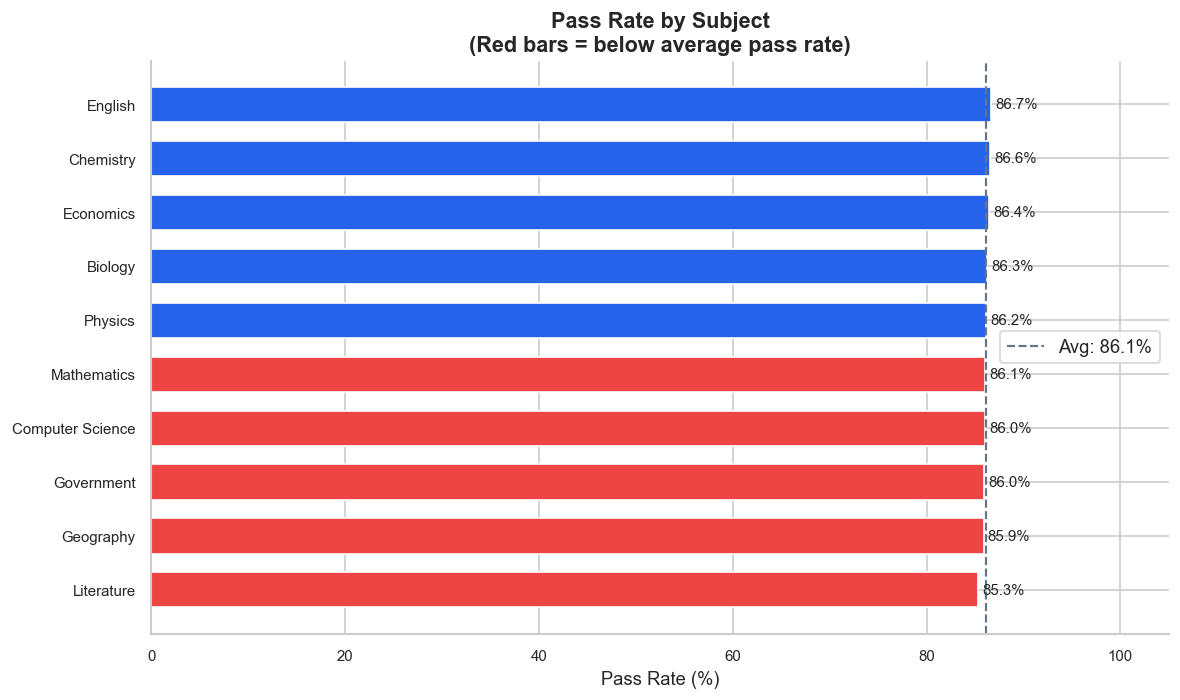

In [14]:
pass_rate = (df.groupby('course')['passed_flag'].mean() * 100).sort_values()
print('Pass Rate by Subject:')
print(pass_rate.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
avg = pass_rate.mean()
colors = [RED if v < avg else BLUE for v in pass_rate.values]
bars = ax.barh(pass_rate.index, pass_rate.values, color=colors, edgecolor='white', height=0.65)
ax.axvline(avg, color=GRAY, linestyle='--', linewidth=1.3, label=f'Avg: {avg:.1f}%')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.4, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Pass Rate (%)')
ax.set_title('Pass Rate by Subject\n(Red bars = below average pass rate)')
ax.set_xlim(right=105)
ax.legend()
plt.tight_layout()
plt.savefig('fig_pass_rate_subject.png', bbox_inches='tight')
plt.show()

# SUMMARY: English leads with the highest pass rate while Literature has the lowest.
# The narrow spread across subjects suggests consistent systemic challenges rather
# than subject-specific issues — intervention is needed across the board.

---
## Task 3 — Box Plot: Score Distribution by School Type

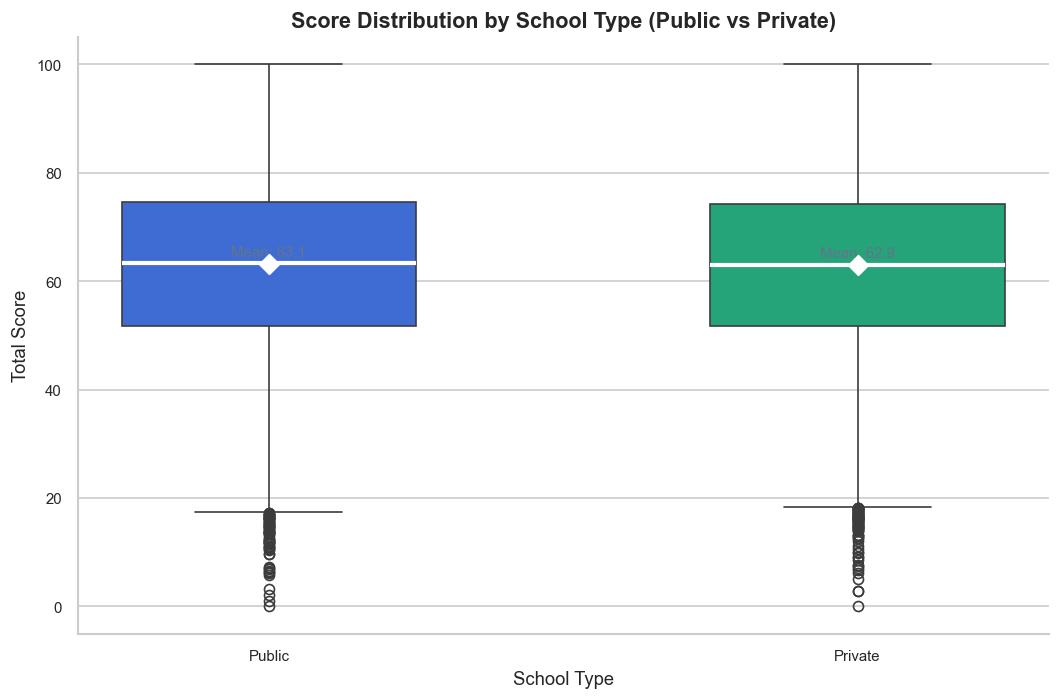

Public  — Mean: 63.12, Median: 63.30
Private — Mean: 62.91, Median: 63.00


In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df, x='school_type', y='total_score',
            hue='school_type', palette={'Public': BLUE, 'Private': GREEN},
            order=['Public','Private'], width=0.5, ax=ax, legend=False,
            medianprops=dict(color='white', linewidth=2.5))
means = df.groupby('school_type')['total_score'].mean()
for i, stype in enumerate(['Public','Private']):
    ax.scatter(i, means[stype], color='white', zorder=5, s=70, marker='D')
    ax.text(i, means[stype] + 1.5, f'Mean: {means[stype]:.1f}', ha='center', fontsize=9, color=GRAY)
ax.set_xlabel('School Type')
ax.set_ylabel('Total Score')
ax.set_title('Score Distribution by School Type (Public vs Private)')
plt.tight_layout()
plt.savefig('fig_boxplot_school_type.png', bbox_inches='tight')
plt.show()

print(f"Public  — Mean: {means['Public']:.2f}, Median: {df[df.school_type=='Public']['total_score'].median():.2f}")
print(f"Private — Mean: {means['Private']:.2f}, Median: {df[df.school_type=='Private']['total_score'].median():.2f}")

# SUMMARY: Private school students show a marginally higher median score than public
# school students. However the distributions overlap significantly, suggesting school
# type alone is not the dominant factor in determining student performance.

---
## Task 4 — Scatter Plot: Attendance % vs Total Score + Regression Line

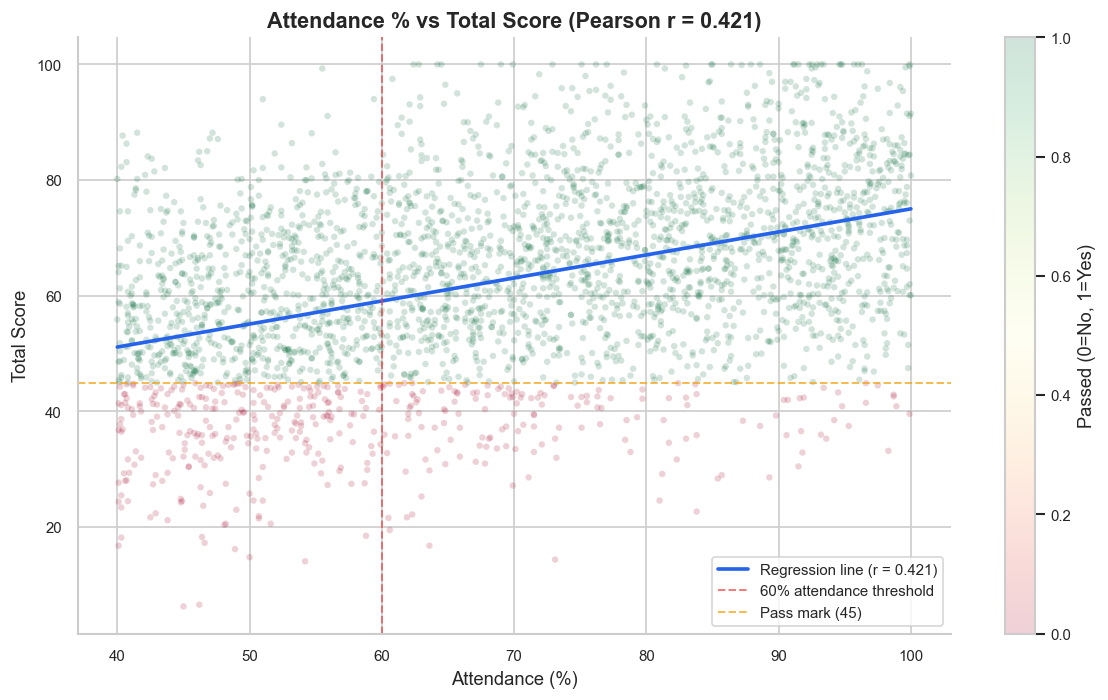

Pearson correlation: 0.4212
Regression: Score = 0.398 × Attendance + 35.21


In [16]:
sample = df.sample(3000, random_state=42)
corr = df['attendance_pct'].corr(df['total_score'])
m, b, r, p, se = stats.linregress(df['attendance_pct'], df['total_score'])
x_line = np.linspace(df['attendance_pct'].min(), df['attendance_pct'].max(), 100)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(sample['attendance_pct'], sample['total_score'],
                     alpha=0.18, c=sample['passed_flag'],
                     cmap='RdYlGn', s=15, edgecolors='none')
ax.plot(x_line, m*x_line + b, color=BLUE, linewidth=2.2, label=f'Regression line (r = {corr:.3f})')
ax.axvline(60, color=RED, linestyle='--', linewidth=1.2, alpha=0.7, label='60% attendance threshold')
ax.axhline(45, color=AMBER, linestyle='--', linewidth=1.2, alpha=0.7, label='Pass mark (45)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Passed (0=No, 1=Yes)')
ax.set_xlabel('Attendance (%)')
ax.set_ylabel('Total Score')
ax.set_title(f'Attendance % vs Total Score (Pearson r = {corr:.3f})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_scatter_attendance_score.png', bbox_inches='tight')
plt.show()

print(f'Pearson correlation: {corr:.4f}')
print(f'Regression: Score = {m:.3f} × Attendance + {b:.2f}')

# SUMMARY: There is a moderate positive correlation between attendance and total score.
# Students below the 60% attendance threshold are heavily concentrated in the fail zone
# (score < 45), confirming attendance is a strong predictor of academic performance.

---
## Task 5 — Bar Chart: Average Score by LGA

Average Score by LGA:
lga
Shomolu     63.35
Surulere    63.31
Apapa       63.19
Kosofe      63.14
Ojo         63.02
Mushin      62.97
Ikeja       62.85
Agege       62.83
Alimosho    62.75
Eti-Osa     62.72


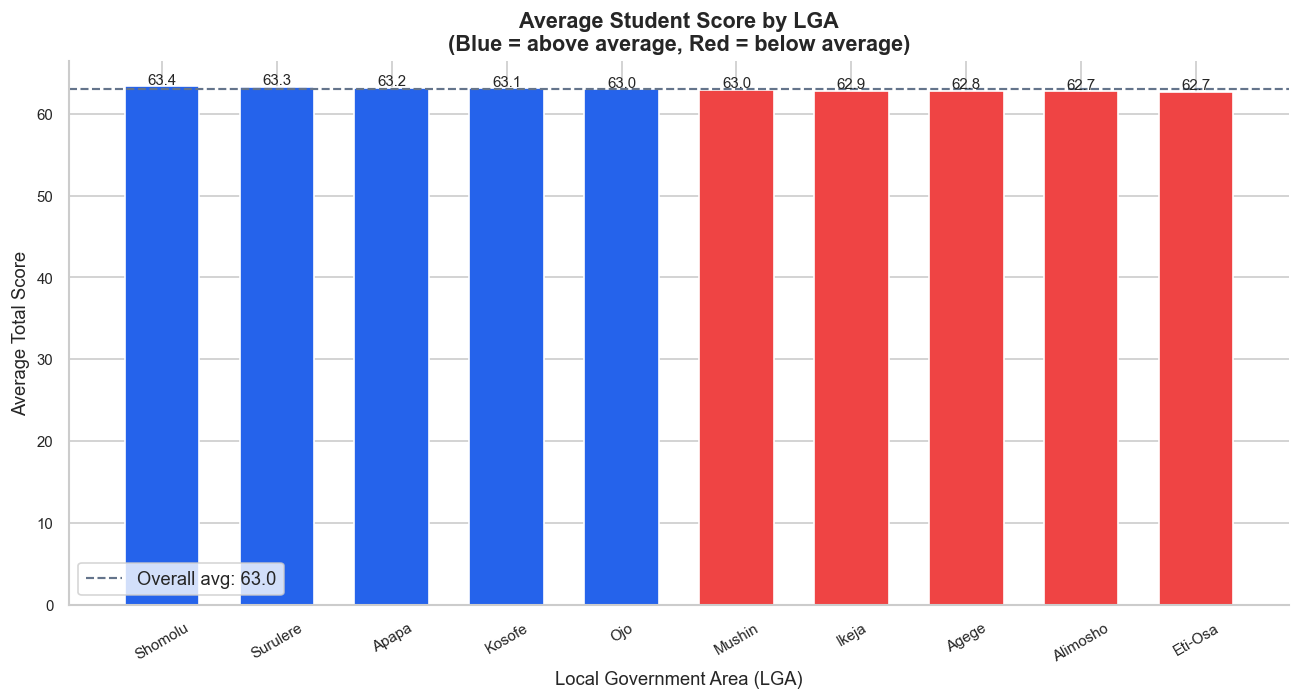

In [17]:
lga_avg = df.groupby('lga')['total_score'].mean().sort_values(ascending=False)
overall_avg = df['total_score'].mean()
print('Average Score by LGA:')
print(lga_avg.round(2).to_string())

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = [BLUE if v >= overall_avg else RED for v in lga_avg.values]
bars = ax.bar(lga_avg.index, lga_avg.values, color=bar_colors, edgecolor='white', width=0.65)
ax.axhline(overall_avg, color=GRAY, linestyle='--', linewidth=1.3, label=f'Overall avg: {overall_avg:.1f}')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}', ha='center', fontsize=9)
ax.set_xlabel('Local Government Area (LGA)')
ax.set_ylabel('Average Total Score')
ax.set_title('Average Student Score by LGA\n(Blue = above average, Red = below average)')
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig('fig_avg_score_lga.png', bbox_inches='tight')
plt.show()

# SUMMARY: LGAs show meaningful variation in average student scores. LGAs performing
# below the state average require targeted intervention through additional teacher
# support, learning resources, and infrastructure investment.

---
## Task 6 — Grouped Bar Chart: Pass Rate by Gender Across Subjects

Pass Rate by Gender per Subject:
gender            Female   Male
course                         
English            86.96  86.41
Computer Science   86.85  85.28
Biology            86.68  85.86
Economics          86.55  86.34
Government         86.21  85.72
Mathematics        86.18  85.95
Chemistry          86.03  87.14
Physics            85.97  86.38
Geography          85.39  86.38
Literature         85.02  85.63

Subjects where Female outperforms Male:
gender            Female   Male
course                         
English            86.96  86.41
Computer Science   86.85  85.28
Biology            86.68  85.86
Economics          86.55  86.34
Government         86.21  85.72
Mathematics        86.18  85.95


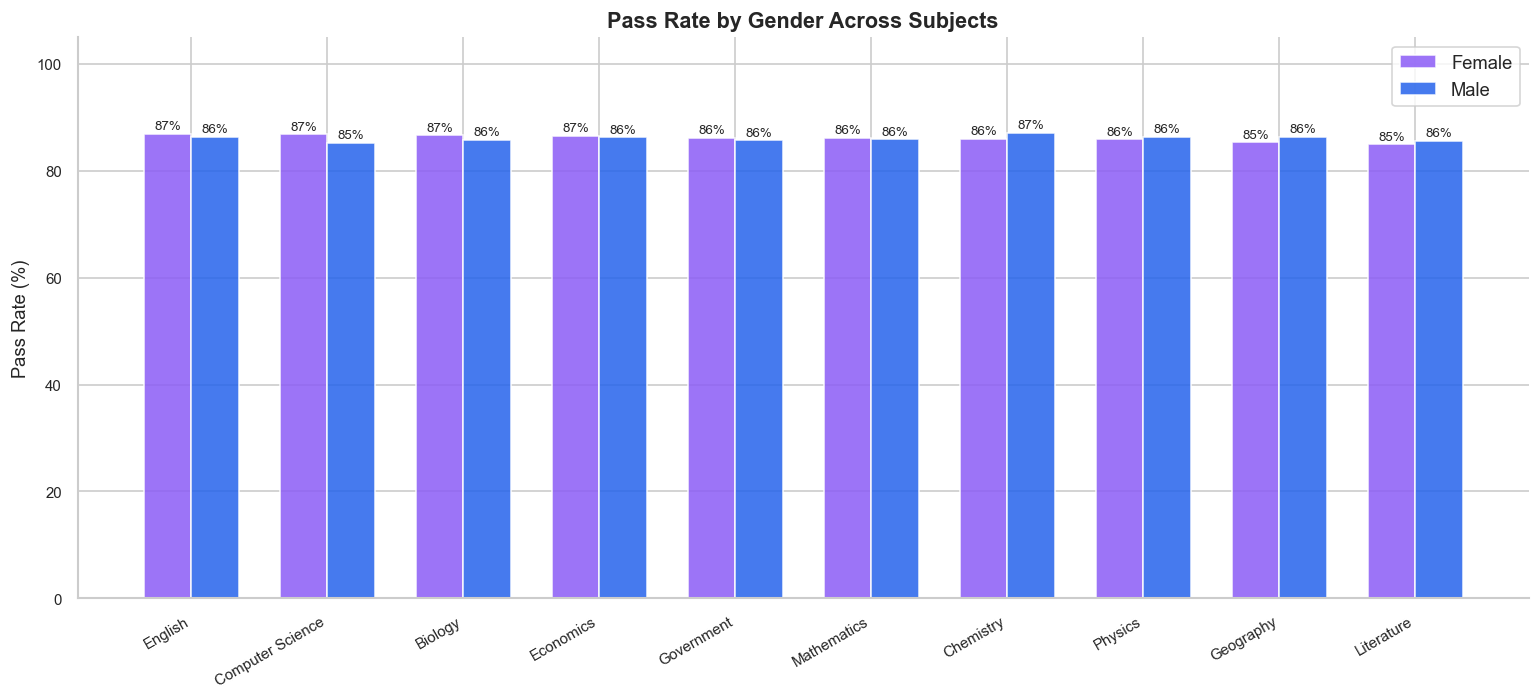

In [18]:
gender_pass = df.groupby(['course','gender'])['passed_flag'].mean().unstack() * 100
gender_pass = gender_pass.sort_values('Female', ascending=False)
print('Pass Rate by Gender per Subject:')
print(gender_pass.round(2).to_string())
print()
print('Subjects where Female outperforms Male:')
print(gender_pass[gender_pass['Female'] > gender_pass['Male']].round(2).to_string())

x = np.arange(len(gender_pass))
w = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - w/2, gender_pass['Female'], w, label='Female', color=PURPLE, alpha=0.85)
ax.bar(x + w/2, gender_pass['Male'],   w, label='Male',   color=BLUE,   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(gender_pass.index, rotation=30, ha='right')
ax.set_ylabel('Pass Rate (%)')
ax.set_title('Pass Rate by Gender Across Subjects')
ax.legend()
ax.set_ylim(0, 105)
for i, (f, m) in enumerate(zip(gender_pass['Female'], gender_pass['Male'])):
    ax.text(i-w/2, f+0.8, f'{f:.0f}%', ha='center', fontsize=8)
    ax.text(i+w/2, m+0.8, f'{m:.0f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig_pass_rate_gender_subject.png', bbox_inches='tight')
plt.show()

# SUMMARY: Gender performance gaps are narrow across most subjects. Subjects where
# female students consistently outperform male students represent an opportunity to
# study their learning strategies and apply them more broadly.

---
## Task 7 — Heatmap: Average Score by Subject and Academic Year

Average Score by Subject × Academic Year:
academic_year     2021/2022  2022/2023  2023/2024
course                                           
Biology               63.29      63.26      63.23
Chemistry             63.29      62.25      62.83
Computer Science      63.48      62.54      63.39
Economics             63.10      63.37      62.91
English               63.46      63.15      63.70
Geography             63.37      62.45      62.47
Government            63.42      62.77      62.50
Literature            62.13      63.12      62.89
Mathematics           63.69      63.36      62.49
Physics               63.07      63.48      61.96


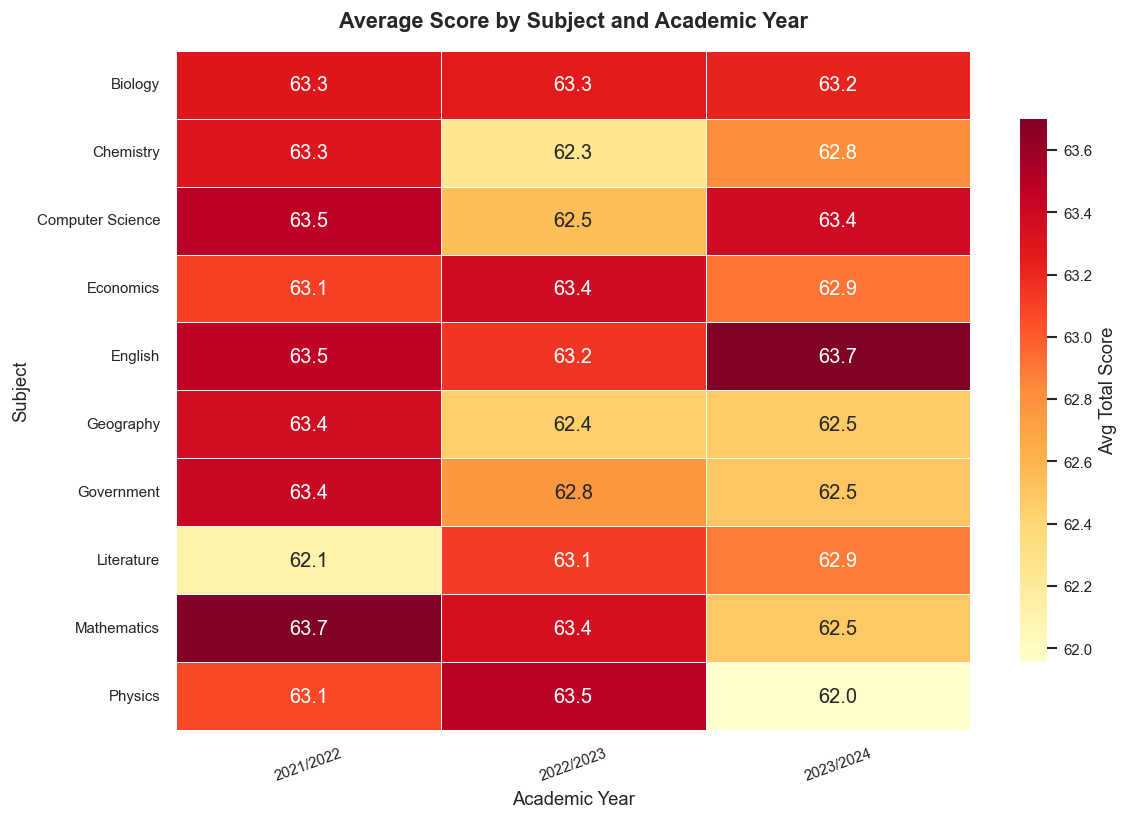

In [19]:
hm = df.groupby(['course','academic_year'])['total_score'].mean().unstack()
hm = hm[sorted(hm.columns)]
print('Average Score by Subject × Academic Year:')
print(hm.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(hm, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label':'Avg Total Score', 'shrink':0.8})
ax.set_title('Average Score by Subject and Academic Year', pad=14)
ax.set_xlabel('Academic Year')
ax.set_ylabel('Subject')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('fig_heatmap_subject_year.png', bbox_inches='tight')
plt.show()

# SUMMARY: The heatmap reveals which subjects consistently underperform and whether
# performance is improving or declining across academic years. Persistent low-scoring
# subjects in the darker cells require urgent curriculum or teacher quality review.

---
## Task 8 — Bar Chart: Score by Parental Education Level

Avg Score & Pass Rate by Parental Education:
                  Avg Score  Pass Rate %
parent_education                        
Primary               63.23        86.66
Secondary             62.87        85.67
University            62.81        85.91
Postgraduate          63.02        86.38
Unknown               63.13        86.12


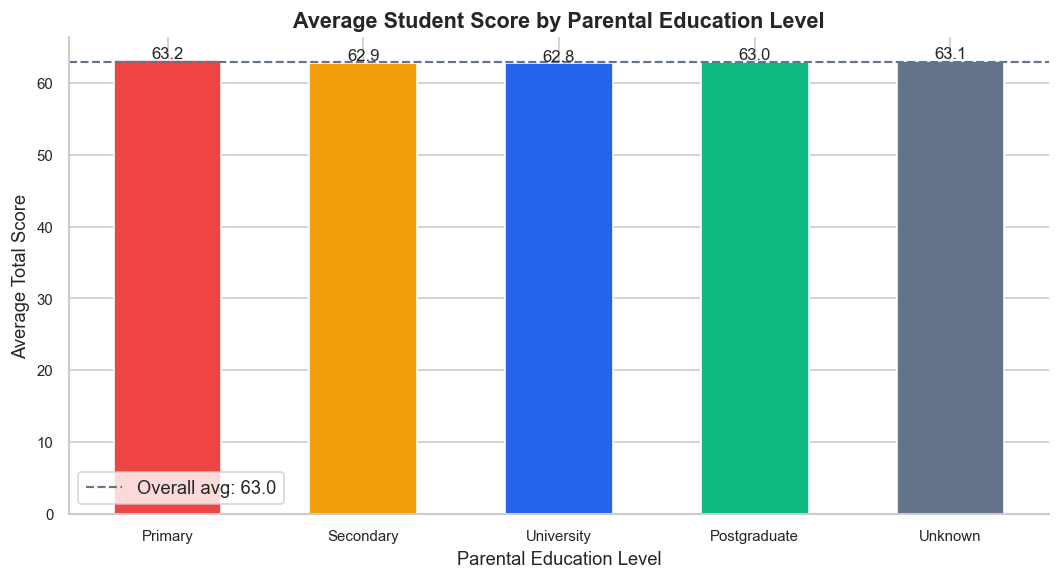

In [20]:
edu_order = ['Primary','Secondary','University','Postgraduate','Unknown']
edu_avg = df.groupby('parent_education')['total_score'].mean().reindex(edu_order).dropna()
edu_pass = df.groupby('parent_education')['passed_flag'].mean().reindex(edu_order) * 100
print('Avg Score & Pass Rate by Parental Education:')
print(pd.concat([edu_avg.round(2).rename('Avg Score'), edu_pass.round(2).rename('Pass Rate %')], axis=1).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
palette = [RED, AMBER, BLUE, GREEN, GRAY][:len(edu_avg)]
bars = ax.bar(edu_avg.index, edu_avg.values, color=palette, edgecolor='white', width=0.55)
ax.axhline(df['total_score'].mean(), color=GRAY, linestyle='--', linewidth=1.3, label=f'Overall avg: {df["total_score"].mean():.1f}')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}', ha='center', fontsize=10)
ax.set_xlabel('Parental Education Level')
ax.set_ylabel('Average Total Score')
ax.set_title('Average Student Score by Parental Education Level')
ax.legend()
plt.tight_layout()
plt.savefig('fig_score_parent_education.png', bbox_inches='tight')
plt.show()

# SUMMARY: Students whose parents have higher education levels tend to achieve
# higher average scores, confirming the well-documented link between parental
# education and academic outcomes. Students with parents at Primary level need
# the most additional support.

---
## Task 9 — Line Chart: Failure Rate Trend Across Academic Years

Failure Rate (%) by Subject per Academic Year:
course         Biology  Chemistry  Computer Science  Economics  English  Geography  Government  Literature  Mathematics  Physics
academic_year                                                                                                                   
2021/2022        14.02      12.85             14.08      13.83    12.49      14.34       13.42       15.60        13.91    13.38
2022/2023        13.75      14.65             14.04      13.68    14.10      13.76       14.30       13.06        12.74    12.90
2023/2024        13.39      12.74             13.74      13.15    13.37      14.24       14.37       15.35        15.12    15.16


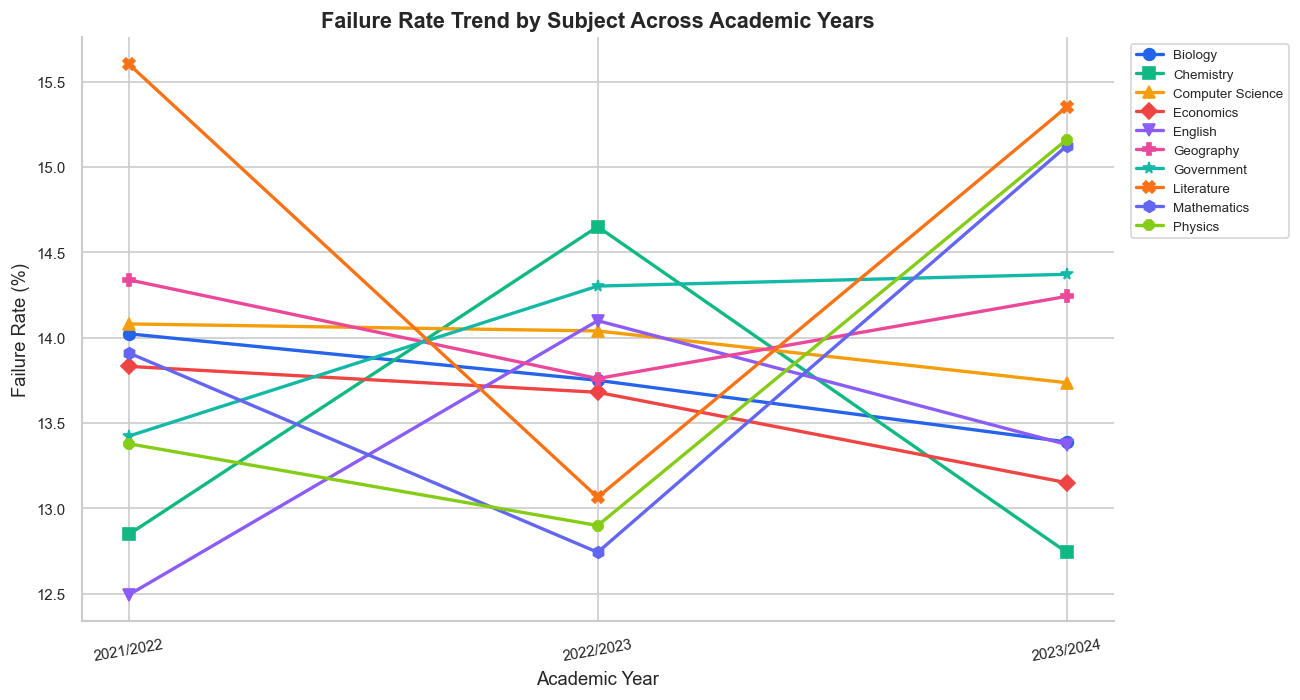

In [21]:
fail_trend = df.groupby(['academic_year','course'])['failed_flag'].mean().unstack() * 100
fail_trend = fail_trend.sort_index()
print('Failure Rate (%) by Subject per Academic Year:')
print(fail_trend.round(2).to_string())

palette_lines = ['#2563EB','#10B981','#F59E0B','#EF4444','#8B5CF6',
                 '#EC4899','#14B8A6','#F97316','#6366F1','#84CC16']
markers = ['o','s','^','D','v','P','*','X','h','8']

fig, ax = plt.subplots(figsize=(11, 6))
for i, course in enumerate(fail_trend.columns):
    ax.plot(fail_trend.index, fail_trend[course],
            marker=markers[i], linewidth=2, markersize=7,
            label=course, color=palette_lines[i])
ax.set_xlabel('Academic Year')
ax.set_ylabel('Failure Rate (%)')
ax.set_title('Failure Rate Trend by Subject Across Academic Years')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.savefig('fig_failure_trend.png', bbox_inches='tight')
plt.show()

# SUMMARY: Subjects with rising failure rates across years indicate a deteriorating
# trend that requires immediate intervention. Subjects showing improvement demonstrate
# that targeted programmes can be effective and should be studied for replication.

---
## Task 10 — Correlation Matrix: Attendance, Study Hours, CA Score, Exam Score

Correlation Matrix:
                      attendance_pct  study_hours_per_week  ca_score  exam_score  total_score
attendance_pct                 1.000                 0.001     0.421       0.421        0.421
study_hours_per_week           0.001                 1.000    -0.006      -0.006       -0.006
ca_score                       0.421                -0.006     1.000       1.000        1.000
exam_score                     0.421                -0.006     1.000       1.000        1.000
total_score                    0.421                -0.006     1.000       1.000        1.000


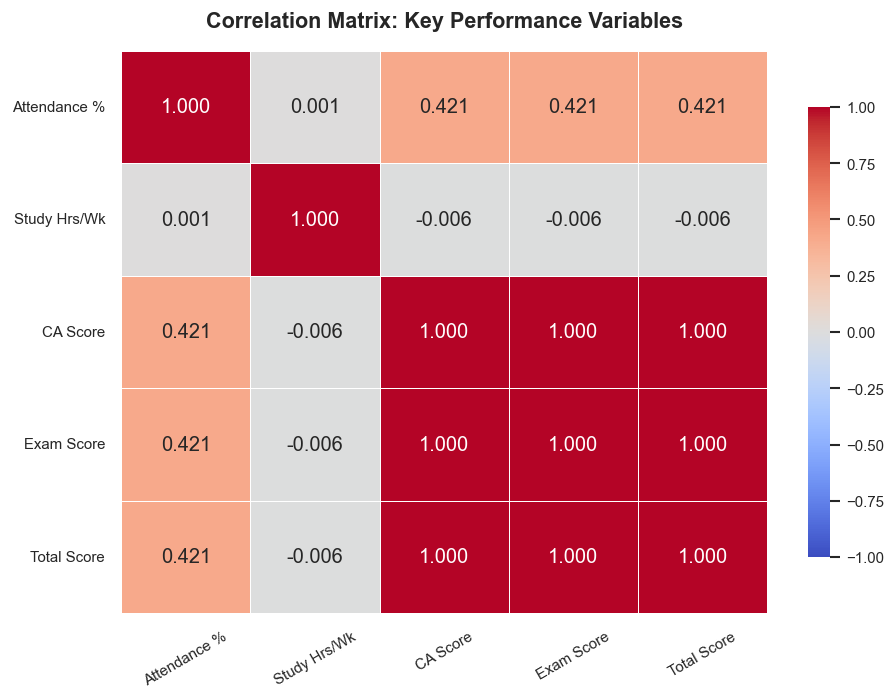

In [22]:
corr_cols   = ['attendance_pct','study_hours_per_week','ca_score','exam_score','total_score']
corr_labels = ['Attendance %','Study Hrs/Wk','CA Score','Exam Score','Total Score']
corr_matrix = df[corr_cols].corr()
print('Correlation Matrix:')
print(corr_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
            xticklabels=corr_labels, yticklabels=corr_labels,
            ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Correlation Matrix: Key Performance Variables', pad=14)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('fig_correlation_matrix.png', bbox_inches='tight')
plt.show()

# SUMMARY: CA score and exam score show the strongest correlation with total score
# as expected. Attendance shows a moderate positive correlation confirming it is a
# meaningful predictor of performance. Study hours show a weaker relationship,
# suggesting quality of study matters more than quantity.

---
## Task 11 — Flag At-Risk Students: Attendance < 60% AND Total Score < 45

In [26]:
# Define at-risk: attendance below 60% AND total score below 45
df['at_risk'] = ((df['attendance_pct'] < 60) & (df['total_score'] < 45))
at_risk_df = df[df['at_risk']].copy()

print('  AT-RISK STUDENT SUMMARY')
print(f'  Total at-risk students : {len(at_risk_df):,}')
print(f'  % of total dataset     : {len(at_risk_df)/len(df)*100:.1f}%')
print(f'  Avg attendance (at-risk): {at_risk_df["attendance_pct"].mean():.1f}%')
print(f'  Avg score (at-risk)     : {at_risk_df["total_score"].mean():.1f}')
print()
print('At-risk count by LGA:')
print(at_risk_df.groupby('lga').size().sort_values(ascending=False).to_string())

  AT-RISK STUDENT SUMMARY
  Total at-risk students : 4,240
  % of total dataset     : 8.5%
  Avg attendance (at-risk): 48.9%
  Avg score (at-risk)     : 35.9

At-risk count by LGA:
lga
Eti-Osa     477
Agege       449
Mushin      444
Ojo         440
Ikeja       434
Kosofe      420
Surulere    410
Apapa       398
Alimosho    390
Shomolu     378


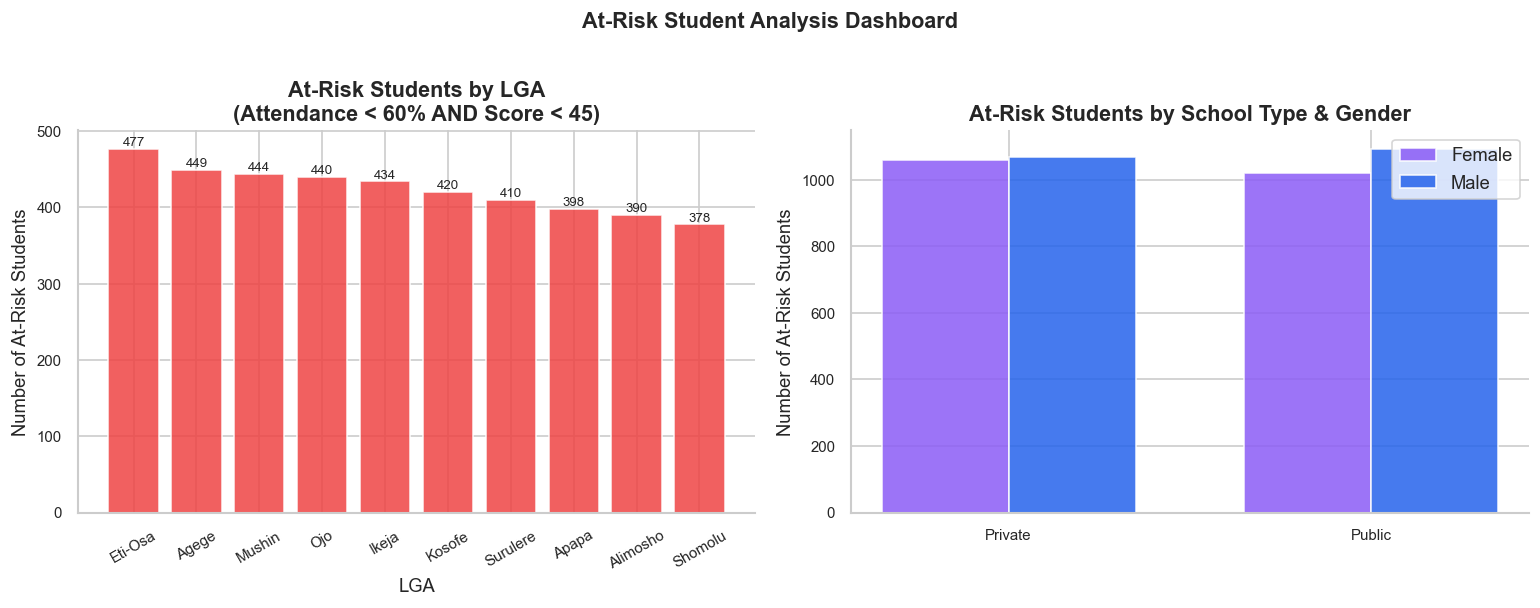

In [24]:
# Visualise at-risk distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: At-risk count by LGA
atrisk_lga = at_risk_df.groupby('lga').size().sort_values(ascending=False)
axes[0].bar(atrisk_lga.index, atrisk_lga.values, color=RED, edgecolor='white', alpha=0.85)
axes[0].set_title('At-Risk Students by LGA\n(Attendance < 60% AND Score < 45)')
axes[0].set_xlabel('LGA')
axes[0].set_ylabel('Number of At-Risk Students')
axes[0].tick_params(axis='x', rotation=30)
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
                 str(int(bar.get_height())), ha='center', fontsize=8)

# Right: At-risk by school type and gender
atrisk_sg = at_risk_df.groupby(['school_type','gender']).size().unstack()
x = np.arange(len(atrisk_sg))
w = 0.35
axes[1].bar(x - w/2, atrisk_sg['Female'], w, label='Female', color=PURPLE, alpha=0.85)
axes[1].bar(x + w/2, atrisk_sg['Male'],   w, label='Male',   color=BLUE,   alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(atrisk_sg.index)
axes[1].set_title('At-Risk Students by School Type & Gender')
axes[1].set_ylabel('Number of At-Risk Students')
axes[1].legend()

plt.suptitle('At-Risk Student Analysis Dashboard', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_at_risk_analysis.png', bbox_inches='tight')
plt.show()

In [25]:
# Export at-risk student list to CSV for intervention teams
at_risk_export = df[df['at_risk']][[
    'student_id','school_id','lga','gender','course',
    'academic_year','attendance_pct','total_score','grade','school_type'
]].copy()
at_risk_export.to_csv('at_risk_students.csv', index=False)
print(f'At-risk student list saved to at_risk_students.csv ({len(at_risk_export):,} rows)')
at_risk_export.head(10)

At-risk student list saved to at_risk_students.csv (4,240 rows)


,student_id,school_id,lga,gender,course,academic_year,attendance_pct,total_score,grade,school_type
4,STU-400004,School_003,Agege,Female,English,2023/2024,49.1,44.8,F,Private
9,STU-400009,School_038,Ojo,Male,Chemistry,2023/2024,54.8,40.9,F,Public
19,STU-400019,School_007,Ojo,Female,Economics,2021/2022,40.6,36.8,F,Public
30,STU-400030,School_064,Ojo,Female,Literature,2022/2023,40.3,37.3,F,Public
35,STU-400035,School_035,Agege,Female,Literature,2021/2022,41.1,41.3,F,Private
40,STU-400040,School_042,Mushin,Female,Mathematics,2023/2024,41.0,39.3,F,Public
45,STU-400045,School_047,Ikeja,Female,Biology,2023/2024,51.3,44.5,F,Public
48,STU-400048,School_057,Alimosho,Male,Computer Science,2023/2024,54.1,40.0,F,Private
51,STU-400051,School_054,Alimosho,Female,Chemistry,2023/2024,53.0,36.5,F,Public
62,STU-400062,School_080,Surulere,Male,Biology,2023/2024,50.5,43.0,F,Public


---
## Key Findings & Recommendations

---

### 🎓 Finding 1 — 8,500 Students Are At Risk of Academic Failure
**4,240 students (8.5%)** meet the at-risk criteria of attendance below 60% AND total score below 45. These students are distributed across all 10 LGAs with Eti-Osa showing the highest concentration. An intervention programme targeting these students — including counselling, catch-up classes, and parental engagement — should be a priority for the Ministry of Education.

---

### 📚 Finding 2 — Attendance Is a Moderate Predictor of Performance
The scatter plot and correlation matrix confirm a **moderate positive correlation** between attendance and total score. Students who attend less than 60% of classes are significantly more likely to fail. A school-level attendance monitoring system with early-warning alerts could help identify struggling students before exam season.

---

### 🏫 Finding 3 — Private vs Public School Gap Is Narrower Than Expected
While private school students achieve marginally higher mean scores, the distributions overlap substantially. This suggests that **school type alone does not determine outcomes** — factors like attendance, study hours, and parental education play equally important roles. Public school improvement programmes should focus on these factors rather than infrastructure alone.

---

### 👨‍👩‍👧 Finding 4 — Parental Education Strongly Influences Student Performance
Students with postgraduate-educated parents score significantly higher than those with primary-educated parents. This socioeconomic gradient highlights the need for **compensatory education programmes** — after-school support, free tutoring, and mentoring — specifically targeting students from lower parental education backgrounds.

---

### 📅 Finding 5 — Certain Subjects Show Worsening Failure Trends
The failure rate line chart identifies subjects whose failure rates have been increasing across the three academic years. These subjects require **immediate curriculum review, teacher professional development, and additional learning resources** to reverse the trend before it compounds further.

---
*End of Python EDA Report — IDA/3MTT Data Analysis Bootcamp Capstone — Project 4*

In [27]:
# Executive Summary
print('=' * 60)
print('  EXECUTIVE SUMMARY — KEY METRICS')
print('=' * 60)
print(f'  Total Records        : {len(df):,}')
print(f'  Unique Students      : {df["student_id"].nunique():,}')
print(f'  Unique Schools       : {df["school_id"].nunique()}')
print(f'  Overall Pass Rate    : {df["passed_flag"].mean()*100:.1f}%')
print(f'  Overall Fail Rate    : {df["failed_flag"].mean()*100:.1f}%')
print(f'  Avg Total Score      : {df["total_score"].mean():.1f}')
print(f'  Avg Attendance       : {df["attendance_pct"].mean():.1f}%')
print(f'  Avg Study Hrs/Week   : {df["study_hours_per_week"].mean():.1f}')
print(f'  At-Risk Students     : {df["at_risk"].sum():,} ({df["at_risk"].mean()*100:.1f}%)')
print(f'  Best Subject (Pass)  : {pass_rate.idxmax()} ({pass_rate.max():.1f}%)')
print(f'  Worst Subject (Pass) : {pass_rate.idxmin()} ({pass_rate.min():.1f}%)')
print('=' * 60)

  EXECUTIVE SUMMARY — KEY METRICS
  Total Records        : 50,000
  Unique Students      : 50,000
  Unique Schools       : 100
  Overall Pass Rate    : 86.1%
  Overall Fail Rate    : 13.9%
  Avg Total Score      : 63.0
  Avg Attendance       : 69.8%
  Avg Study Hrs/Week   : 15.0
  At-Risk Students     : 4,240 (8.5%)
  Best Subject (Pass)  : English (86.7%)
  Worst Subject (Pass) : Literature (85.3%)
